Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df=pd.read_csv("/content/drive/MyDrive/tech_job_market_2019_2026.csv")

In [16]:
df.shape

(115000, 28)

There are 115000 rows and 28 columns

In [17]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

There are 4 float type,3 int type and 21 object type values

In [19]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [20]:
df.isnull().sum()

,0
job_id,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0


In [21]:
df.isnull().sum().sum()

np.int64(87962)

There are 87962 missing values

In [22]:
df.duplicated().sum()

np.int64(1193)

There is 1193 duplicated row

There are many columns to study, so we are going to analyze top 15-20 columns which give more insights of the data

In [23]:
structure = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique Values': df.nunique(dropna=False).values
})


In [24]:
print (structure)

                          Column Data Type  Non-Null Count  Missing Count  \
0                         job_id    object          115000              0   
1                   company_name    object          115000              0   
2                   company_type    object          115000              0   
3                         sector    object          115000              0   
4         company_size_employees     int64          115000              0   
5                     hq_country    object          115000              0   
6                       job_role    object          115000              0   
7                seniority_level    object          115000              0   
8           years_experience_min     int64          115000              0   
9           years_experience_max     int64          115000              0   
10           required_tech_stack    object          115000              0   
11  primary_programming_language    object           92525          22475   

In [25]:
print("Unique values in salary_min_usd:")
print(df['salary_min_usd'].unique()[:30])

print("\nUnique values in salary_max_usd:")
print(df['salary_max_usd'].unique()[:30])

Unique values in salary_min_usd:
['-1' nan '238800.0' '96300.0' '$186,800' '33100.0' '87400.0' '131100.0'
 '114500.0' '42500.0' '72300.0' '115800.0' '126200.0' '226200.0' '82600.0'
 '133400.0' '130900.0' '120600.0' '96900.0' '174800.0' '108600.0'
 '40,600 USD' '250800.0' '60400.0' '54100.0' '152700.0' '206000.0'
 '183500.0' '123900.0' '189200.0']

Unique values in salary_max_usd:
['-1' nan '274700.0' '104000.0' '245400.0' '38500.0' '98100.0' '103900.0'
 '139700.0' '47600.0' '84700.0' '152400.0' '144300.0' '275000.0'
 '106100.0' '146900.0' '172500.0' '157700.0' '117400.0' '189900.0'
 '129300.0' '49400.0' '288300.0' '67800.0' '65100.0' '166400.0' '246100.0'
 '235700.0' '143800.0' '226100.0']


In [26]:
print("Sample salary_min_usd values:")
print(df['salary_min_usd'].sample(20, random_state=42).tolist())

print("\nSample salary_max_usd values:")
print(df['salary_max_usd'].sample(20, random_state=42).tolist())

Sample salary_min_usd values:
['107900.0', '76000.0', '269500.0', '160100.0', '164900.0', '151900.0', '95700.0', '119800.0', '75000.0', '104300.0', '120900.0', '79800.0', '137600.0', '75300.0', '112100.0', '85700.0', '76500.0', '59800.0', '213500.0', '80600.0']

Sample salary_max_usd values:
['138700.0', '95000.0', '357800.0', '181200.0', '181900.0', '174100.0', '125000.0', '129700.0', '85100.0', '116100.0', '151000.0', '100600.0', '183300.0', '90800.0', '126500.0', '115600.0', '88200.0', '75500.0', '259900.0', '102500.0']


UNIVARIATE ANALYSIS

In [27]:
import warnings
warnings.filterwarnings('ignore')

CATEGORICAL VARIABLES

COMPANY_TYPE

In [28]:
print(df['company_type'].value_counts(dropna=False))

company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64


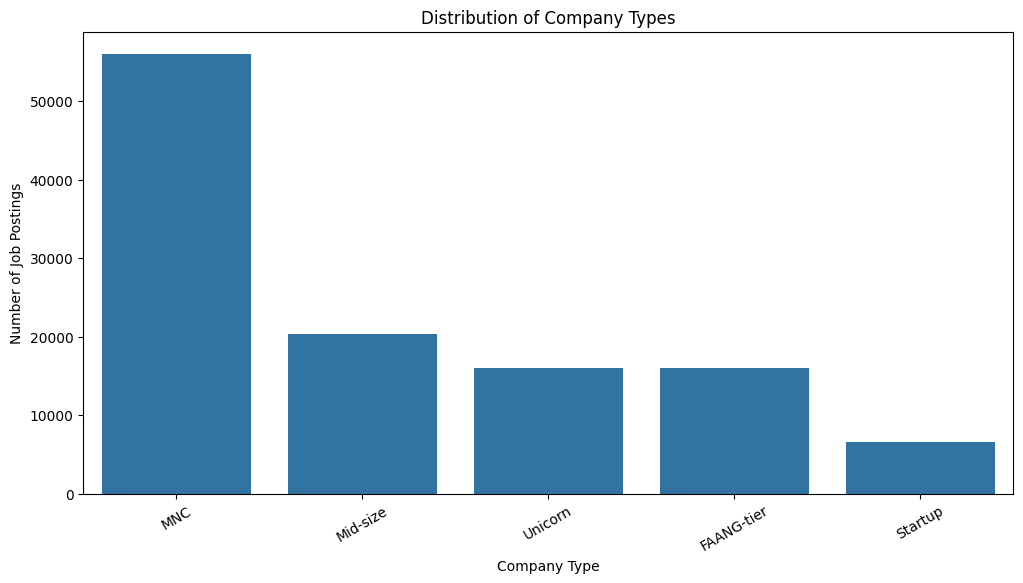

In [29]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='company_type',
    order=df['company_type'].value_counts().index
)

plt.title('Distribution of Company Types')
plt.xlabel('Company Type')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=30)
plt.show()

The distribution shows how job postings are distributed across different company types. This helps identify which types of organizations contribute most to the job market represented in the dataset and here it is MNC.

SECTOR

In [30]:
print(df['sector'].value_counts(dropna=False))

sector
E-commerce       16680
HealthTech       15273
Fintech          13134
EdTech           11523
Social/AdTech     9022
AI/ML             8900
SaaS              8620
Crypto/Web3       8038
Cloud/Infra       6567
Cybersecurity     5739
Logistics         5289
Gaming            5045
e-commerce         175
healthtech         147
fintech            141
edtech             126
social/adtech      100
crypto/web3         89
ai/ml               88
saas                88
cloud/infra         60
gaming              57
cybersecurity       50
logistics           49
Name: count, dtype: int64


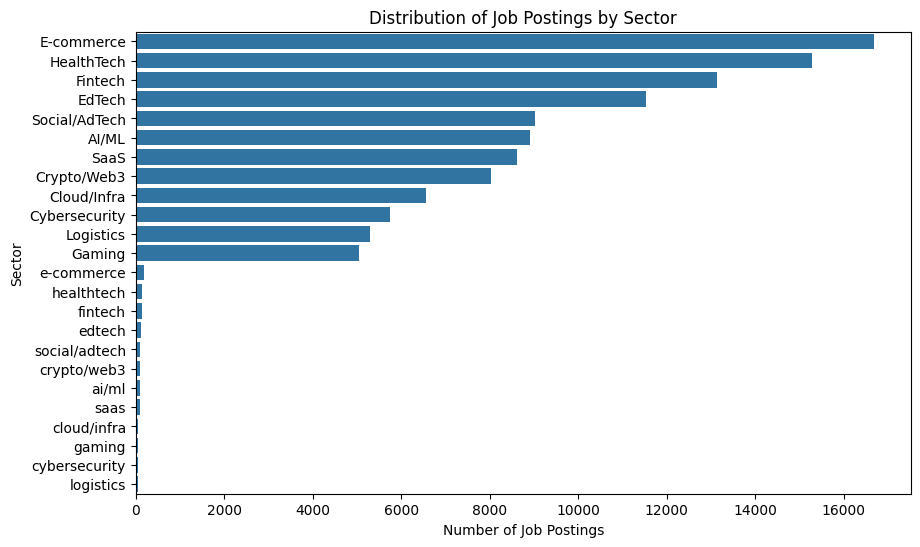

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='sector',
    order=df['sector'].value_counts().index
)

plt.title('Distribution of Job Postings by Sector')
plt.xlabel('Number of Job Postings')
plt.ylabel('Sector')
plt.show()

The sector distribution highlights the industries generating the highest number of job postings and provides an overview of the composition of the technology job market and here it is E-commerce.

JOB_ROLE

In [32]:
top_roles = df['job_role'].value_counts().head(15)

print(top_roles)

job_role
Backend Engineer             6011
Embedded Systems Engineer    5987
QA Engineer                  5910
Software Engineer            5881
Frontend Engineer            5851
Mobile Engineer (iOS)        5793
Full Stack Engineer          5783
Mobile Engineer (Android)    5743
DevOps Engineer              3596
Infrastructure Engineer      3596
Cloud Engineer               3560
Platform Engineer            3552
Site Reliability Engineer    3544
Machine Learning Engineer    3122
Data Analyst                 3105
Name: count, dtype: int64


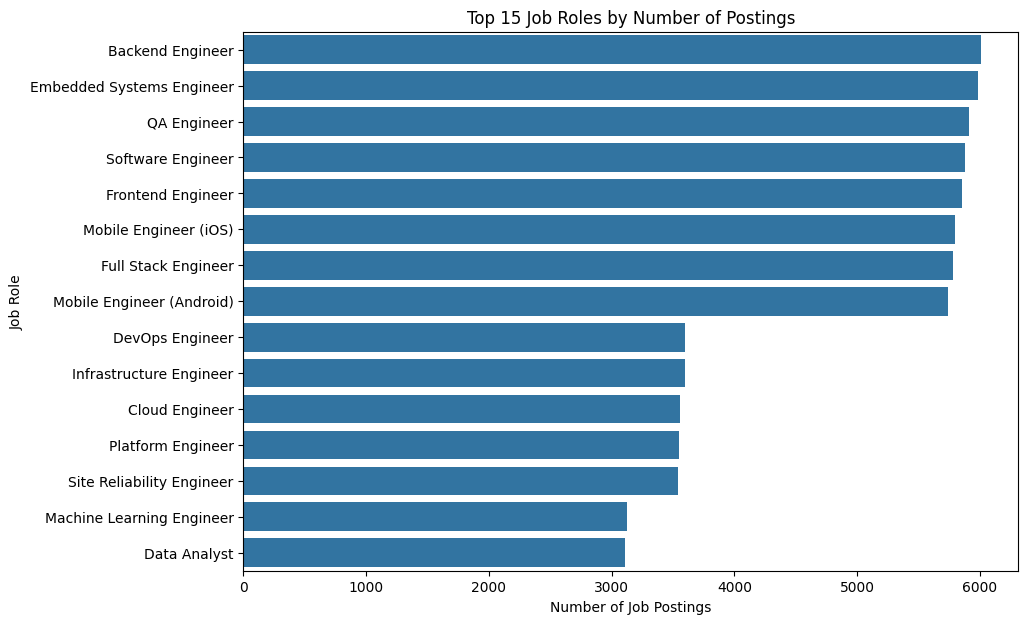

In [33]:
plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.show()

The top job roles reveal which technical and technology-related positions occur most frequently in the dataset. Limiting the visualization to the top 15 roles keeps the distribution readable while the complete frequency table remains available for analysis and here it is backened engineer.

SENIORITY LEVEL

In [36]:
print(df['seniority_level'].value_counts(dropna=False))

seniority_level
Mid          39094
Entry        28621
Senior       23000
Lead         10482
Intern        9251
Principal     4552
Name: count, dtype: int64


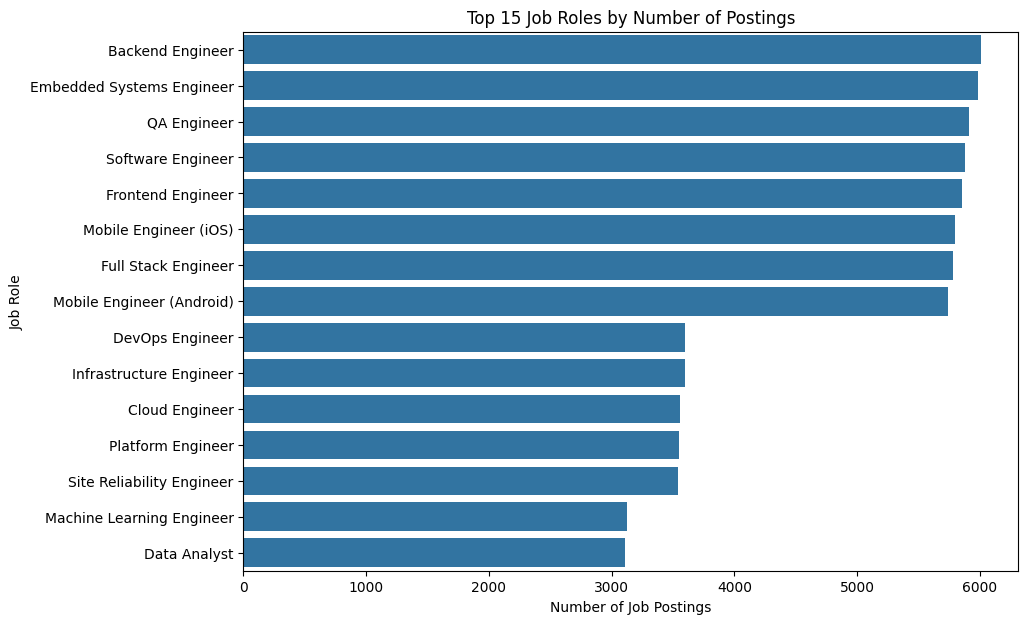

In [37]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_roles.values,
    y=top_roles.index
)

plt.title('Top 15 Job Roles by Number of Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Role')
plt.show()

WORK_MODE

In [39]:
print(df['work_mode'].value_counts(dropna=False))

work_mode
Hybrid            48946
Remote            32320
Onsite            26731
HYBRID             1511
hybrid             1348
remote              598
Work From Home      567
WFH                 557
REMOTE              556
ONSITE              474
onsite              468
In-office           466
On-site             458
Name: count, dtype: int64


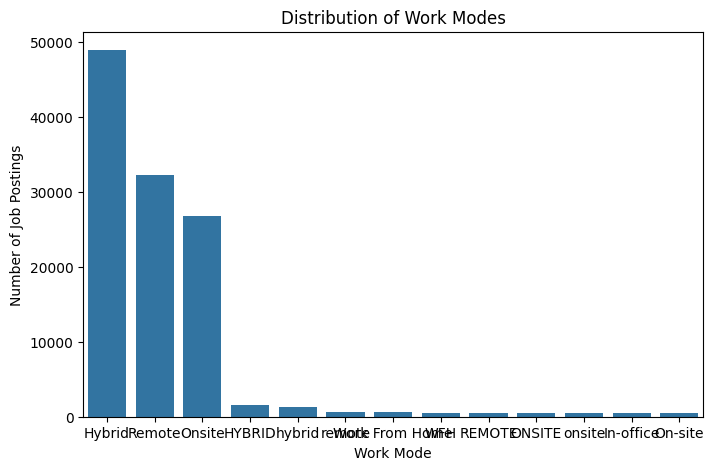

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='work_mode',
    order=df['work_mode'].value_counts().index
)

plt.title('Distribution of Work Modes')
plt.xlabel('Work Mode')
plt.ylabel('Number of Job Postings')
plt.show()

POSITION STATUS

In [ ]:
print(df['position_status'].value_counts(dropna=False))

position_status
Filled       91064
Open         10161
Cancelled     8048
Withdrawn     5727
Name: count, dtype: int64


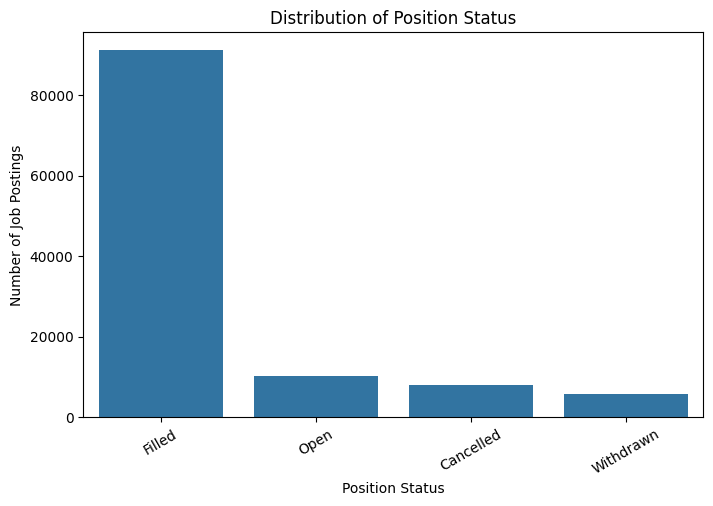

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='position_status',
    order=df['position_status'].value_counts().index
)

plt.title('Distribution of Position Status')
plt.xlabel('Position Status')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=30)
plt.show()

VISA SPONSORSHIP OFFERED

In [40]:
print(df['visa_sponsorship_offered'].value_counts(dropna=False))

visa_sponsorship_offered
0        19831
N        19774
False    19746
No       19545
Yes       9104
True      9032
Y         8988
1         8980
Name: count, dtype: int64


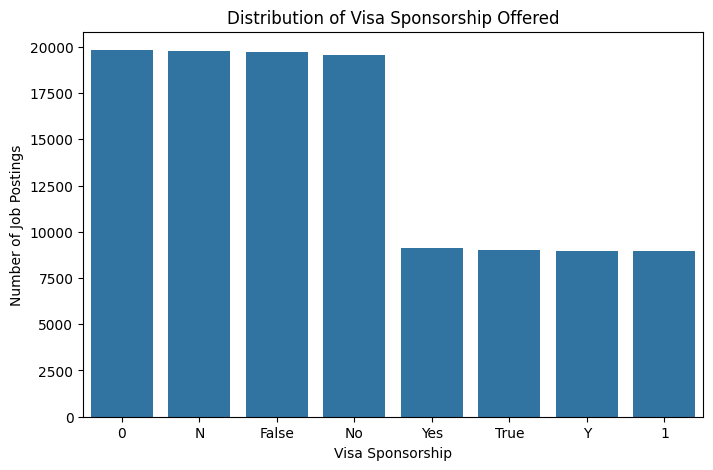

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='visa_sponsorship_offered',
    order=df['visa_sponsorship_offered'].value_counts().index
)

plt.title('Distribution of Visa Sponsorship Offered')
plt.xlabel('Visa Sponsorship')
plt.ylabel('Number of Job Postings')
plt.show()

NUMERICAL VARIABLE

COMPANY SIZE EMPLOYEE

In [42]:
df['company_size_employees'].describe()

,company_size_employees
count,115000.000000
mean,105386.103122
std,102117.290040
min,10.000000
25%,6038.750000
50%,88364.000000
75%,169840.250000
max,488674.000000


HISTOGRAM

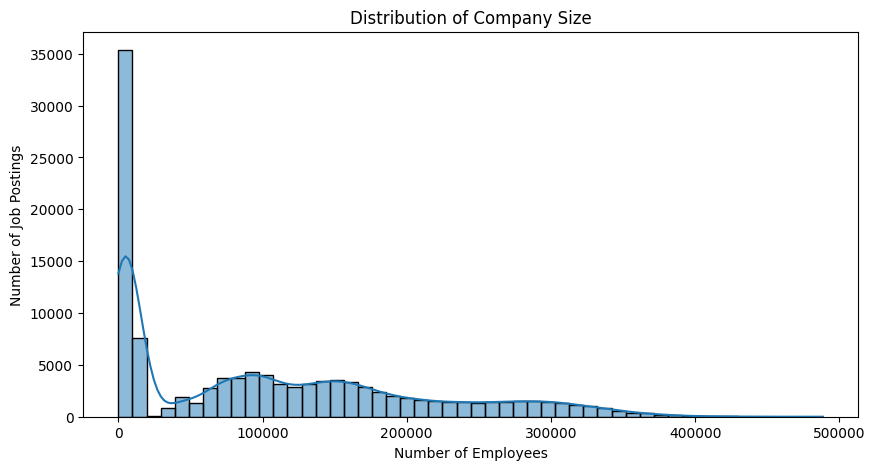

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['company_size_employees'],
    bins=50,
    kde=True
)

plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Number of Job Postings')
plt.show()

BOXPLOT

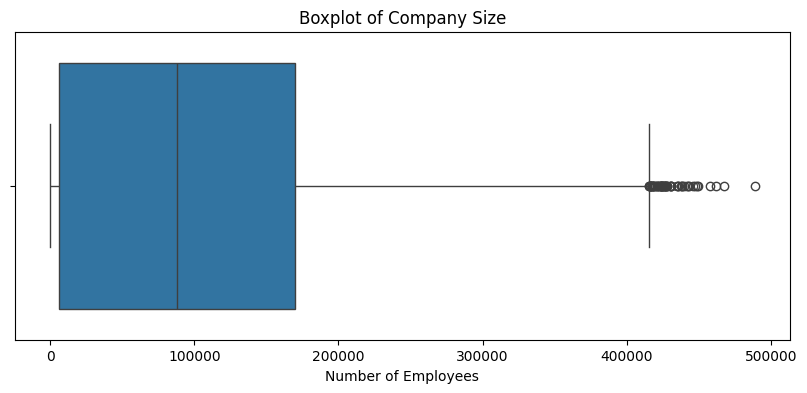

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['company_size_employees'])

plt.title('Boxplot of Company Size')
plt.xlabel('Number of Employees')
plt.show()

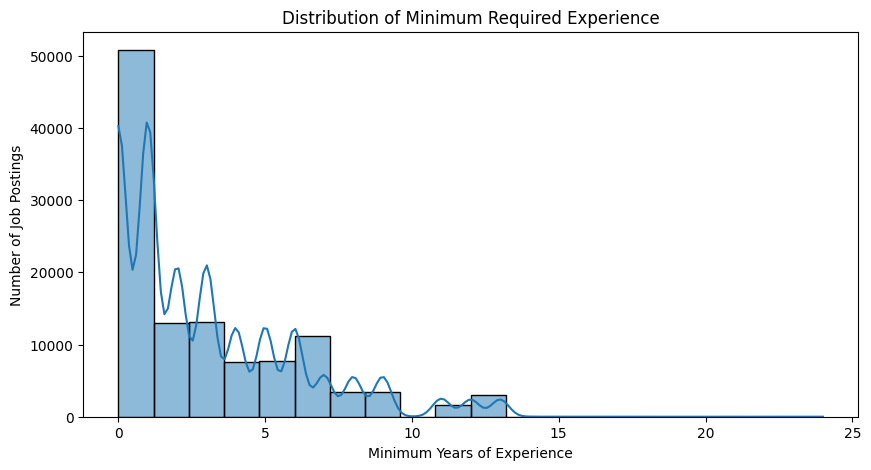

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['years_experience_min'],
    bins=20,
    kde=True
)

plt.title('Distribution of Minimum Required Experience')
plt.xlabel('Minimum Years of Experience')
plt.ylabel('Number of Job Postings')
plt.show()

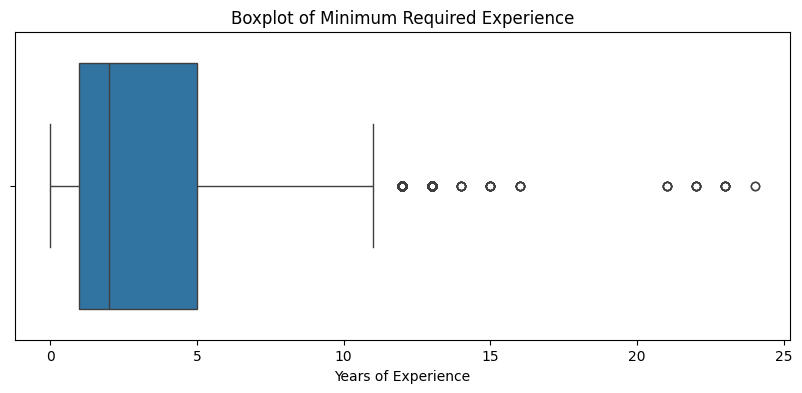

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['years_experience_min'])

plt.title('Boxplot of Minimum Required Experience')
plt.xlabel('Years of Experience')
plt.show()

In [ ]:
df['number_of_applicants'].describe()

,number_of_applicants
count,113890.000000
mean,181.659215
std,436.344753
min,-5.000000
25%,62.000000
50%,119.000000
75%,213.000000
max,36816.000000


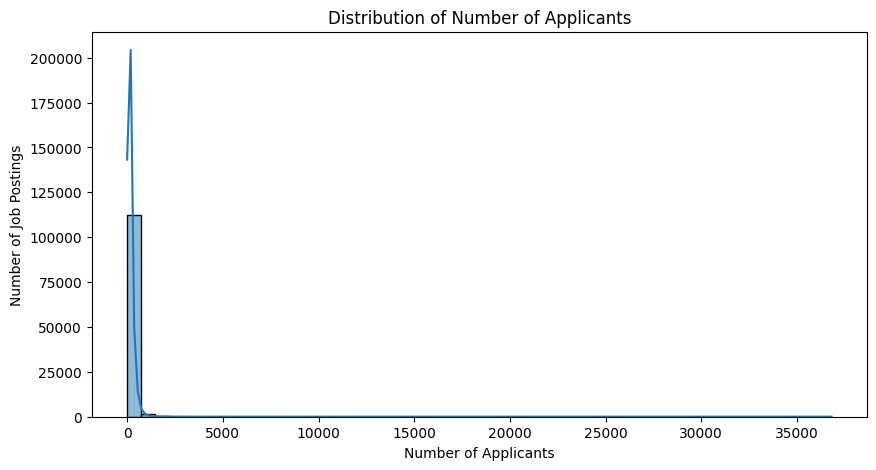

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['number_of_applicants'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('Number of Job Postings')
plt.show()

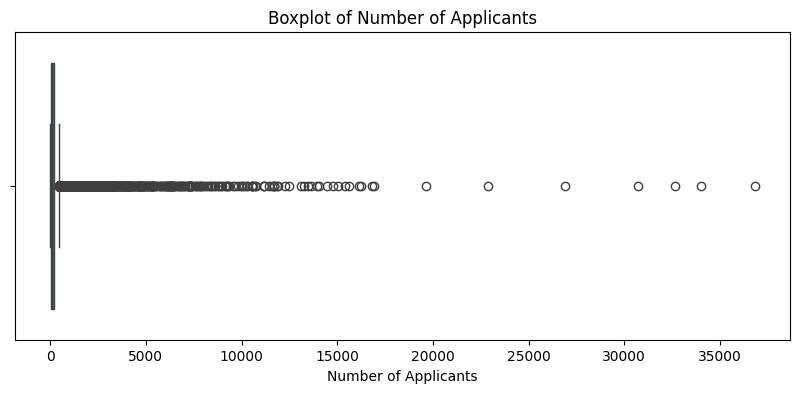

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['number_of_applicants'])

plt.title('Boxplot of Number of Applicants')
plt.xlabel('Number of Applicants')
plt.show()

In [ ]:
df['number_of_interview_rounds'].describe()

,number_of_interview_rounds
count,114564.000000
mean,3.307653
std,1.418283
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,8.000000


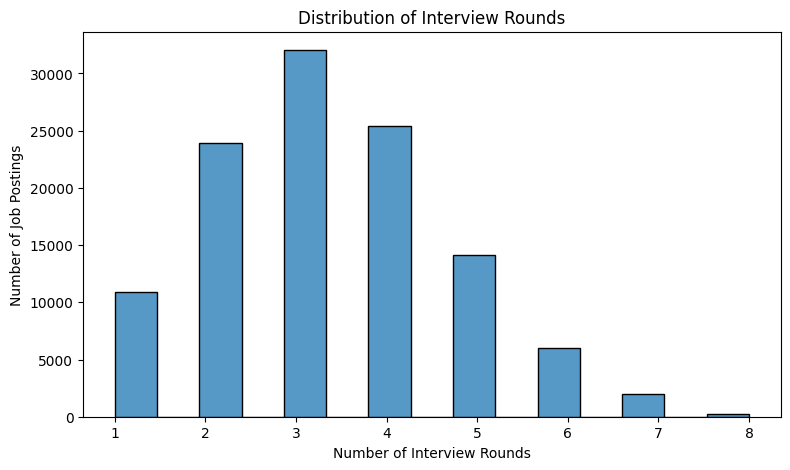

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df['number_of_interview_rounds'].dropna(),
    bins=15,
    kde=False
)

plt.title('Distribution of Interview Rounds')
plt.xlabel('Number of Interview Rounds')
plt.ylabel('Number of Job Postings')
plt.show()

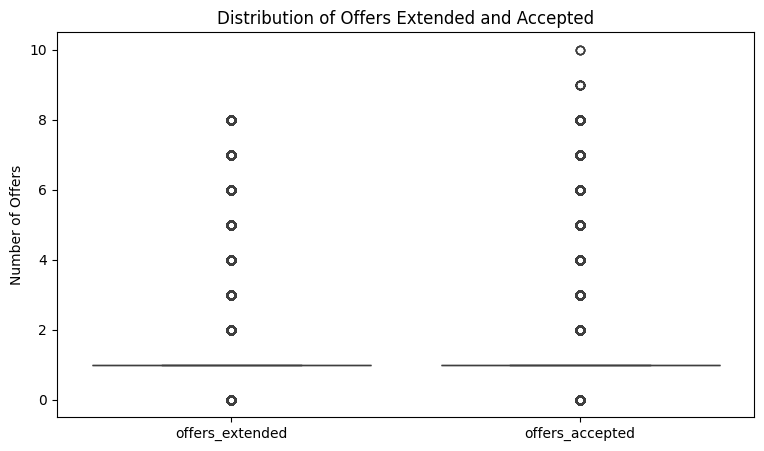

In [ ]:
offers_data = df[
    ['offers_extended', 'offers_accepted']
].melt(
    var_name='Offer Metric',
    value_name='Number of Offers'
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=offers_data,
    x='Offer Metric',
    y='Number of Offers'
)

plt.title('Distribution of Offers Extended and Accepted')
plt.xlabel('')
plt.ylabel('Number of Offers')
plt.show()

In [ ]:
df[
    ['salary_min_usd', 'salary_max_usd']
].describe()

,salary_min_usd,salary_max_usd
count,111682,111682
unique,4795,4157
top,-1,-1
freq,737,737


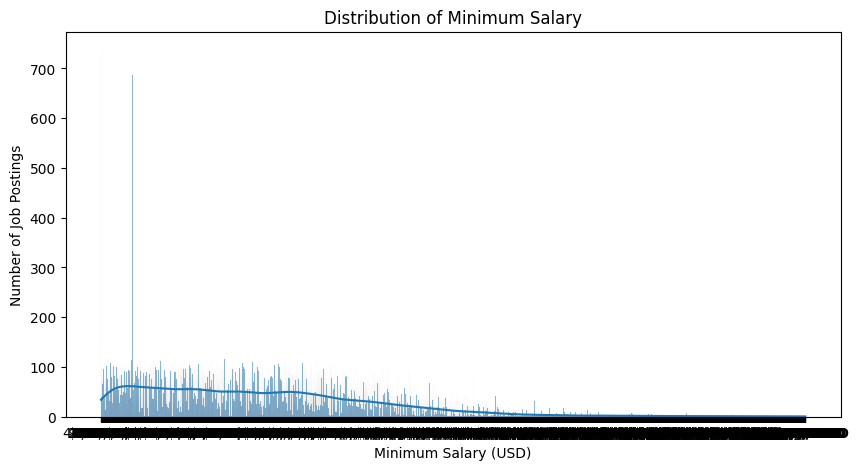

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['salary_min_usd'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Minimum Salary')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Number of Job Postings')
plt.show()

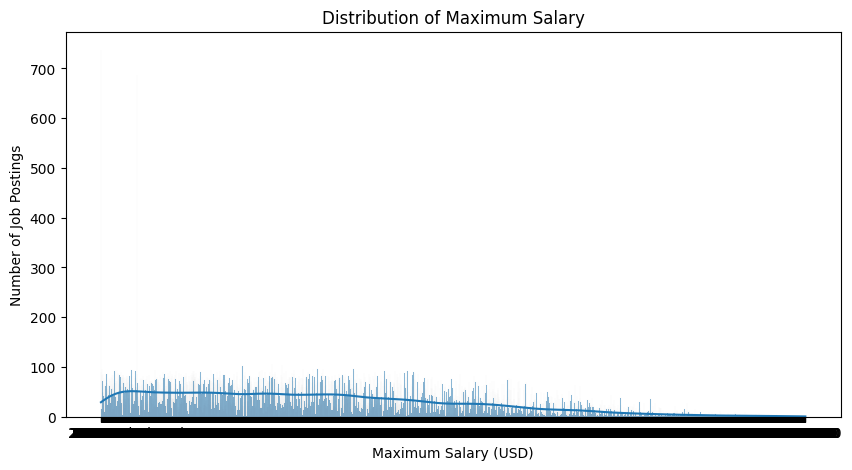

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['salary_max_usd'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Maximum Salary')
plt.xlabel('Maximum Salary (USD)')
plt.ylabel('Number of Job Postings')
plt.show()

In [ ]:
top_languages = df['primary_programming_language'].value_counts().head(15)

print(top_languages)

primary_programming_language
Python        19390
Go            14665
Bash           5975
Java           5921
JavaScript     5883
C++            5801
Kotlin         5798
Swift          5780
TypeScript     5774
Scala          4505
R              4474
SQL            4429
C              3037
Unknown         556
TBD             537
Name: count, dtype: int64


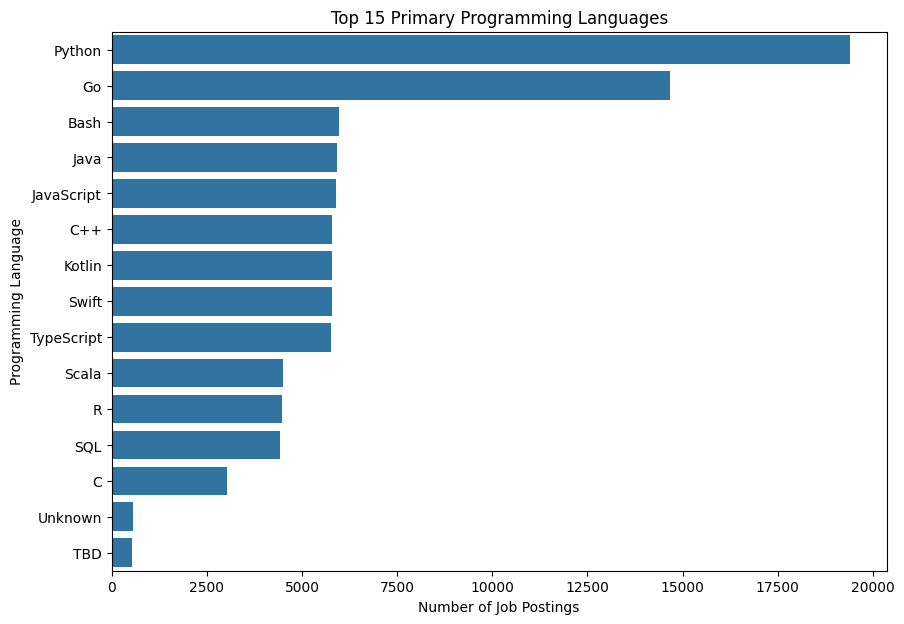

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_languages.values,
    y=top_languages.index
)

plt.title('Top 15 Primary Programming Languages')
plt.xlabel('Number of Job Postings')
plt.ylabel('Programming Language')
plt.show()

BIVARIATE ANALYSIS

Work Mode vs Salary

In [ ]:
df[['salary_min_usd', 'salary_max_usd']].head(20)

,salary_min_usd,salary_max_usd
0,-1,-1
1,NaN,NaN
2,238800.0,274700.0
3,96300.0,104000.0
4,"$186,800",245400.0
5,33100.0,38500.0
6,87400.0,98100.0
7,131100.0,103900.0
8,114500.0,139700.0
9,42500.0,47600.0


In [ ]:
print(df['salary_min_usd'].dtype)
print(df['salary_max_usd'].dtype)

object
object


In [ ]:
def clean_salary(series):
    return (
        series
        .astype('string')
        .str.replace(r'[$,]', '', regex=True)
        .str.replace(r'\s*USD\s*', '', regex=True, case=False)
        .str.strip()
        .replace(['', 'nan', '-1', '-1-1'], np.nan)
        .pipe(pd.to_numeric, errors='coerce')
    )

df['salary_min_usd'] = clean_salary(df['salary_min_usd'])
df['salary_max_usd'] = clean_salary(df['salary_max_usd'])

In [ ]:
print(df['salary_min_usd'].dtype)
print(df['salary_max_usd'].dtype)

Float64
Float64


In [ ]:
df['avg_salary'] = df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

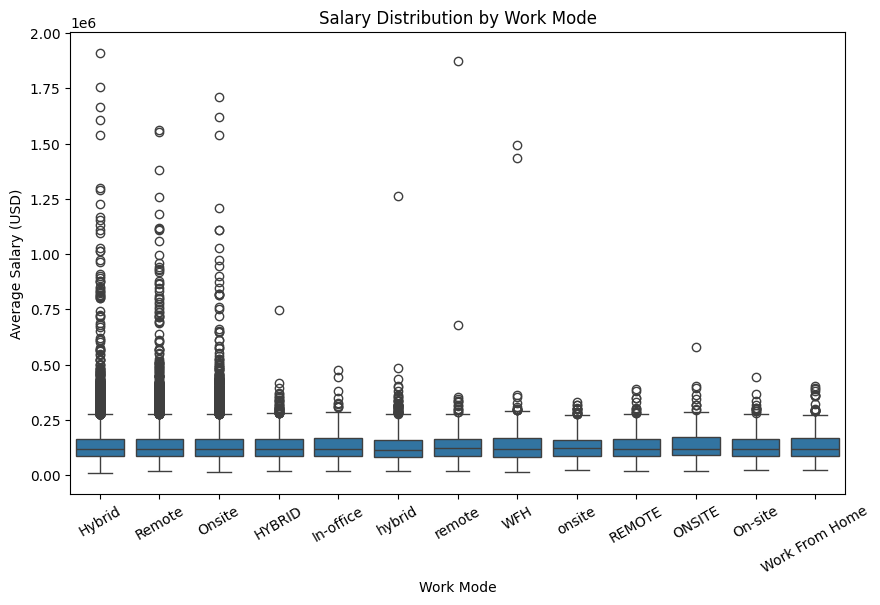

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='work_mode', y='avg_salary')

plt.title('Salary Distribution by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('work_mode')['avg_salary'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
work_mode,,,,,
HYBRID,1445,129138.93,116700.0,17500.0,746650.0
Hybrid,46938,128900.11,117300.0,10300.0,1910150.0
In-office,444,130399.61,118175.0,20050.0,473950.0
ONSITE,453,133742.88,120250.0,19600.0,577800.0
On-site,437,132259.04,118900.0,21250.0,442550.0
Onsite,25641,128911.49,116800.0,15200.0,1709700.0
REMOTE,529,128648.86,119600.0,17000.0,388900.0
Remote,30979,129112.15,117450.0,16550.0,1559900.0
WFH,535,133280.93,117950.0,16100.0,1495300.0


### Observation

The boxplot compares salary distributions across different work modes.
The median salary and overall spread vary across work modes, while several
outliers can also be observed. The groupby summary provides the numerical
comparison of the salary distributions.

seniority level vs salary

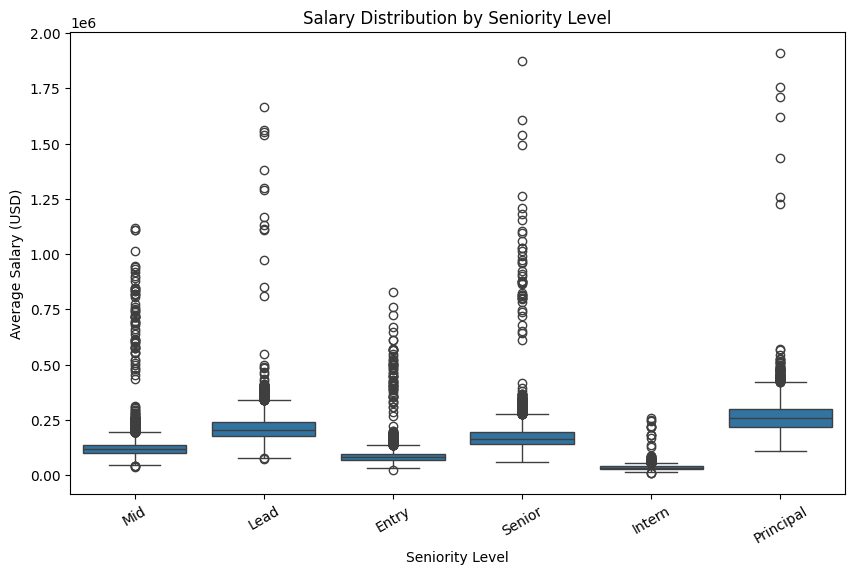

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='seniority_level', y='avg_salary')

plt.title('Salary Distribution by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('seniority_level')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2).sort_values('median', ascending=False)

,count,mean,median
seniority_level,,,
Principal,4022,266709.61,257075.0
Lead,9318,212819.82,205150.0
Senior,22259,172652.44,165650.0
Mid,37910,122513.68,117750.0
Entry,27770,85342.73,81800.0
Intern,8980,35169.93,33800.0


### Observation

Salary distribution was compared across different seniority levels.
The median salary and salary spread show how compensation varies with
experience and seniority.

work mode vs number of applicants

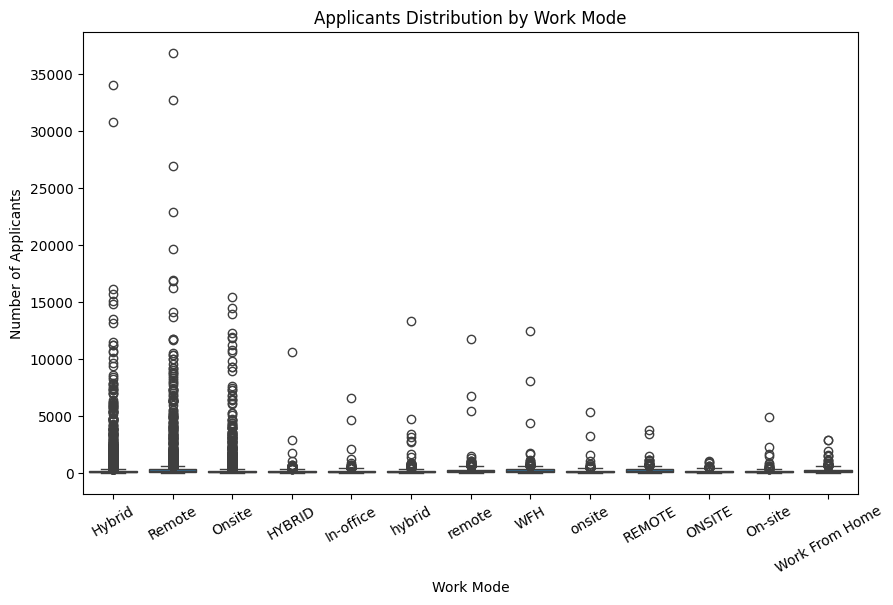

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='work_mode', y='number_of_applicants')

plt.title('Applicants Distribution by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('work_mode')['number_of_applicants'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

,count,mean,median,max
work_mode,,,,
HYBRID,1496,145.22,102.5,10584.0
Hybrid,48478,153.12,103.0,34034.0
In-office,462,165.61,97.0,6562.0
ONSITE,469,139.61,101.0,1071.0
On-site,455,148.39,101.0,4921.0
Onsite,26482,156.91,105.0,15392.0
REMOTE,551,234.37,165.0,3712.0
Remote,32002,245.19,166.0,36816.0
WFH,552,262.63,168.0,12474.0


### Observation

Salary distribution was compared across different seniority levels.
The median salary and salary spread show how compensation varies with
experience and seniority.

sector vs salary

In [ ]:
top_sectors = df['sector'].value_counts().head(10).index

sector_df = df[df['sector'].isin(top_sectors)]

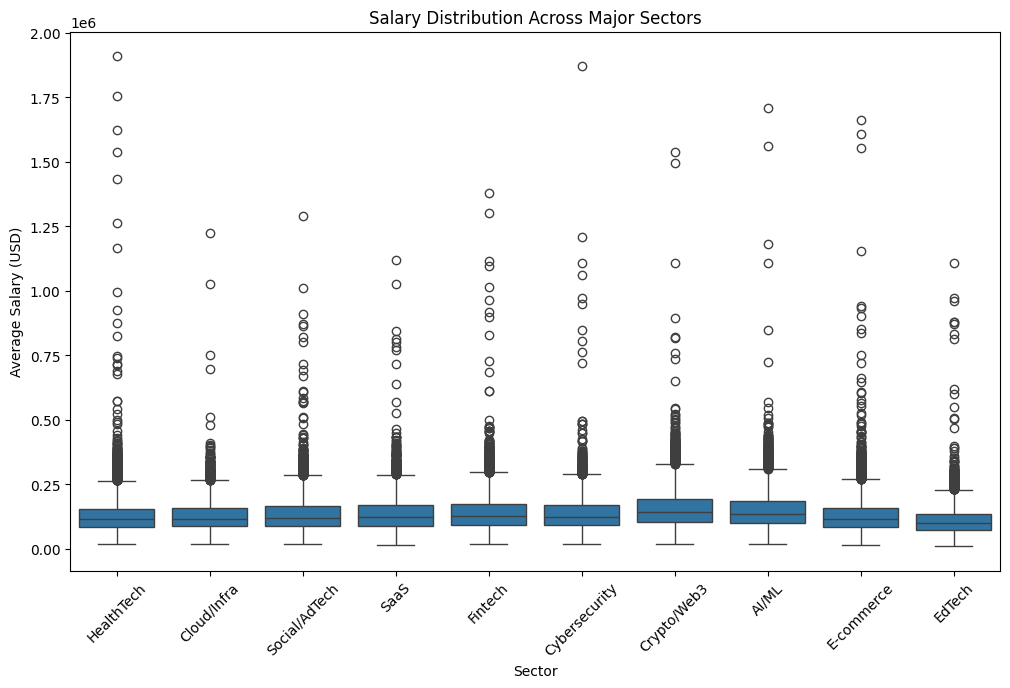

In [ ]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sector_df,
    x='sector',
    y='avg_salary'
)

plt.title('Salary Distribution Across Major Sectors')
plt.xlabel('Sector')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)

plt.show()

In [ ]:
sector_df.groupby('sector')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2).sort_values('median', ascending=False)

,count,mean,median
sector,,,
Crypto/Web3,7593,153953.31,142050.0
AI/ML,8610,147137.77,134925.0
Fintech,12664,137648.0,126450.0
Cybersecurity,5491,137000.17,124150.0
SaaS,8185,132815.58,121850.0
Social/AdTech,8626,132506.83,120800.0
Cloud/Infra,6320,127036.05,116450.0
E-commerce,15962,125454.94,114200.0
HealthTech,14562,125177.16,113550.0


### Observation

Salary distributions were compared across the major sectors in the dataset. The results show differences in median salary and salary spread between sectors. Some sectors also contain noticeable salary outliers. This indicates that the sector of a job can be an important factor when comparing salary levels.


Seniority vs applicants

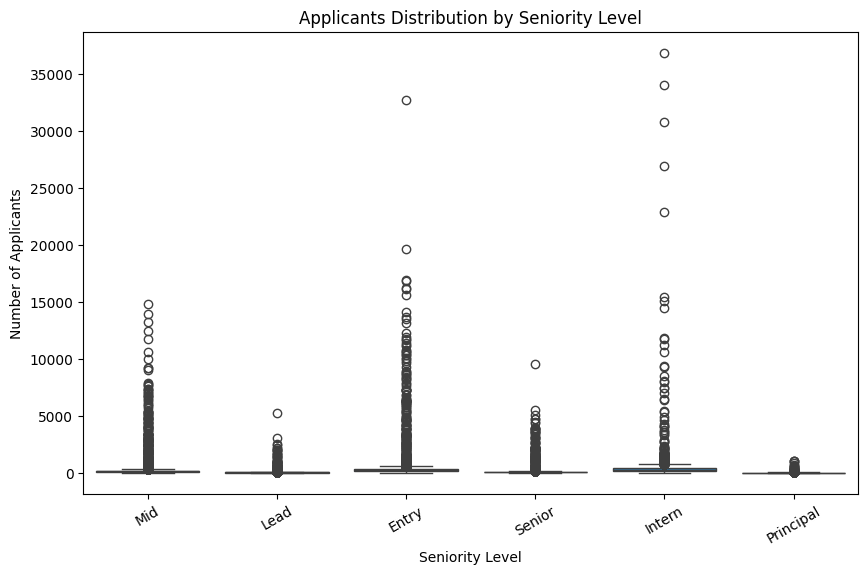

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='seniority_level',
    y='number_of_applicants'
)

plt.title('Applicants Distribution by Seniority Level')
plt.xlabel('Seniority Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('seniority_level')['number_of_applicants'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
seniority_level,,,
Entry,28337,290.15,214.0
Intern,9159,375.75,277.0
Lead,10370,46.56,34.0
Mid,38700,163.81,123.0
Principal,4526,24.01,18.0
Senior,22798,91.90,69.0


### Observation

The number of applicants was compared across different seniority levels. The distribution of applicants is not the same for all seniority categories, and some categories show a wider spread than others. Outliers are also present, indicating that some job postings received considerably more applications than others.


Interview round vs position status

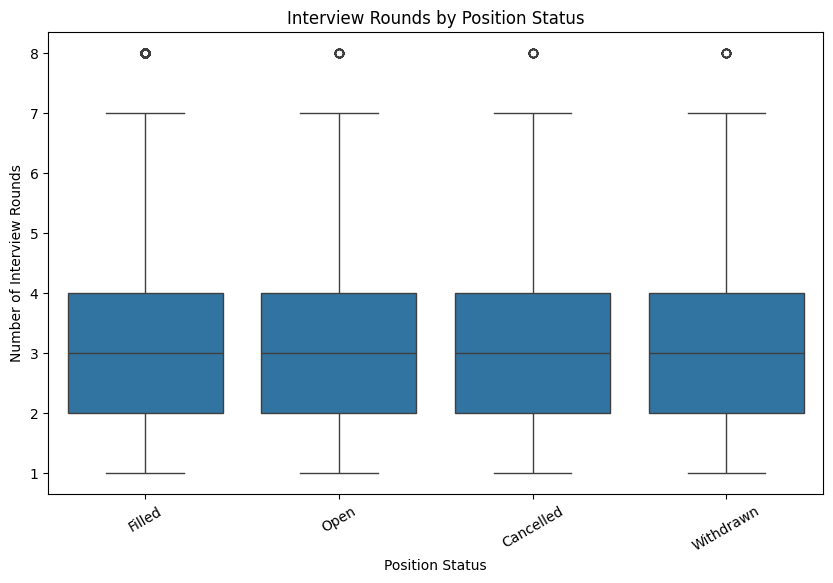

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='position_status',
    y='number_of_interview_rounds'
)

plt.title('Interview Rounds by Position Status')
plt.xlabel('Position Status')
plt.ylabel('Number of Interview Rounds')
plt.xticks(rotation=30)

plt.show()

In [ ]:
df.groupby('position_status')['number_of_interview_rounds'].agg(
    ['count', 'mean', 'median', 'max']
).round(2)

,count,mean,median,max
position_status,,,,
Cancelled,8026,3.32,3.0,8.0
Filled,90705,3.31,3.0,8.0
Open,10129,3.33,3.0,8.0
Withdrawn,5704,3.29,3.0,8.0


### Observation

The analysis compares the number of interview rounds with the current status of the job position. The number of interview rounds varies across different position-status categories. This provides an initial view of how the hiring process differs depending on whether a position is open, filled, or in another status.


Applicant vs salary

In [ ]:
plot_df = df[['number_of_applicants', 'avg_salary']].dropna()

plot_df = plot_df.sample(
    min(10000, len(plot_df)),
    random_state=42
)

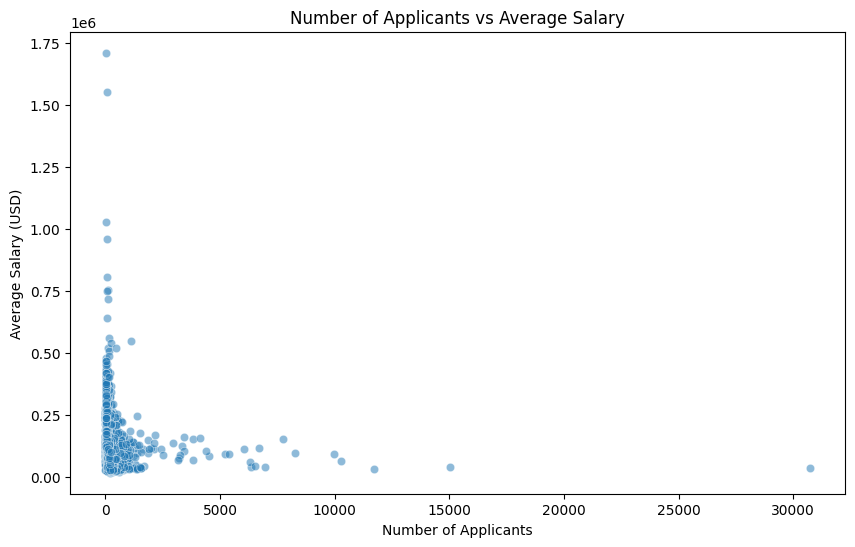

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='number_of_applicants',
    y='avg_salary',
    alpha=0.5
)

plt.title('Number of Applicants vs Average Salary')
plt.xlabel('Number of Applicants')
plt.ylabel('Average Salary (USD)')

plt.show()

### Observation

The scatter plot was used to examine the relationship between the number of applicants and average salary. The points show considerable variation in salary and applicant counts, with no obvious strong linear pattern visible from the plot alone. The correlation value was also calculated to quantify the strength of their linear relationship.


MULTIVARIATE ANALYSIS

work mode vs seniority vs salary

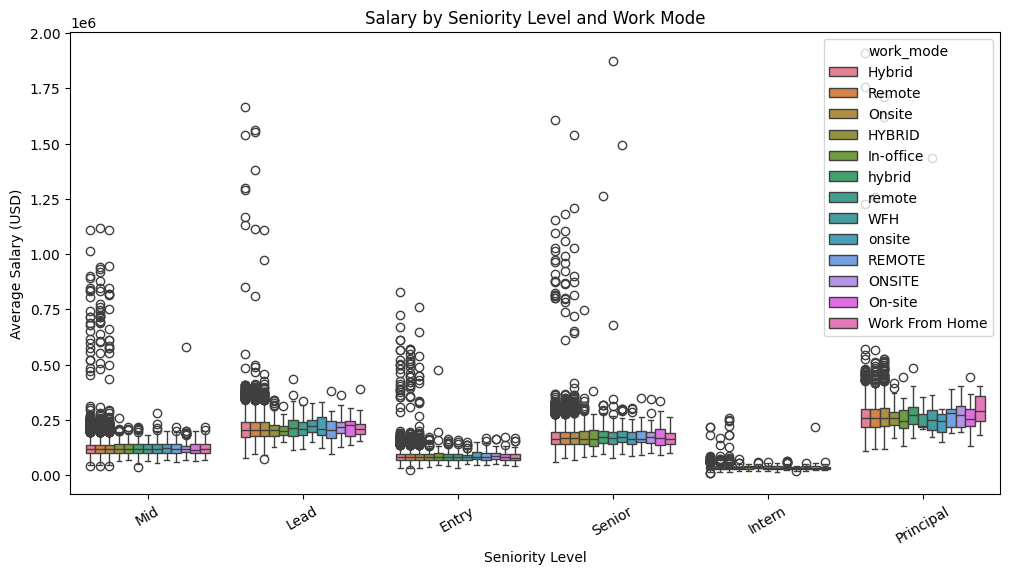

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='seniority_level',
    y='avg_salary',
    hue='work_mode'
)

plt.title('Salary by Seniority Level and Work Mode')
plt.xlabel('Seniority Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=30)

plt.show()

### Observation

Salary distribution was compared across seniority levels while also considering work mode.
The plot shows how salary varies across different combinations of seniority and work arrangement.
This provides a more detailed view than analysing seniority or work mode separately.

sector vs company type vs salary

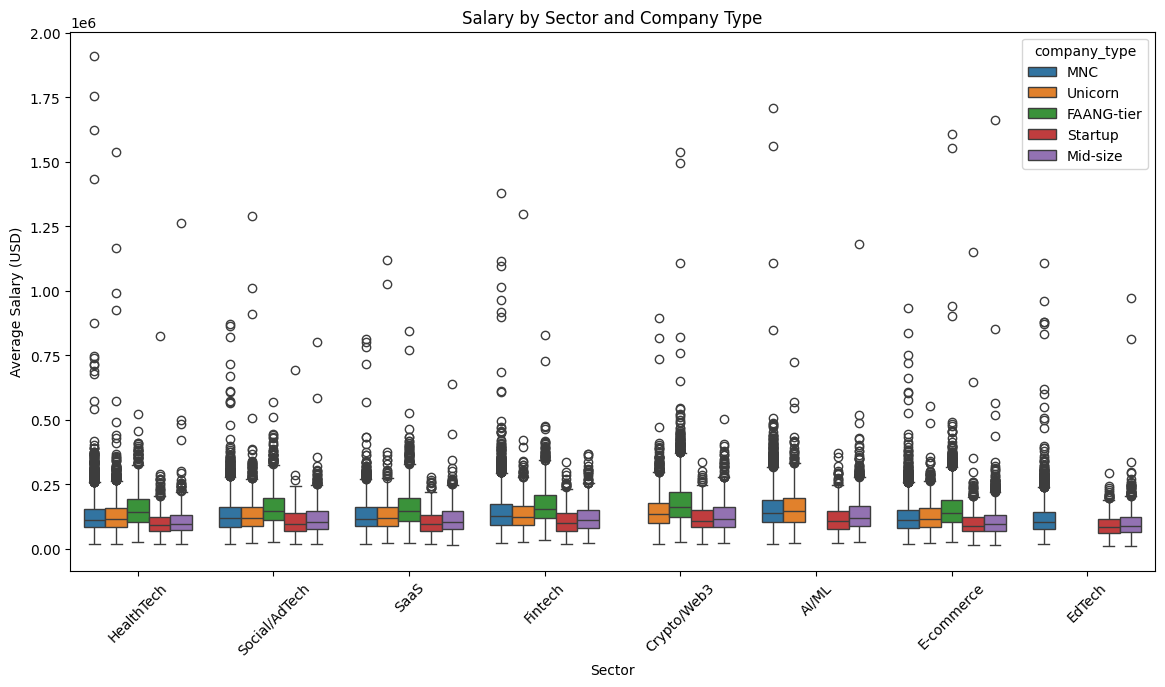

In [ ]:
top_sectors = df['sector'].value_counts().head(8).index

temp_df = df[df['sector'].isin(top_sectors)]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=temp_df,
    x='sector',
    y='avg_salary',
    hue='company_type'
)

plt.title('Salary by Sector and Company Type')
plt.xlabel('Sector')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)

plt.show()

### Observation

Salary was analysed across major sectors while also considering company type.
The results show that salary variation is influenced by more than one factor,
and differences can be observed between combinations of sectors and company types.

TIME BASED ANALYSIS

In [ ]:
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')

In [ ]:
df['posting_year'] = df['posting_date'].dt.year

In [ ]:
yearly_postings = df['posting_year'].value_counts().sort_index()

print(yearly_postings)

posting_year
2019    11592
2020     9788
2021    13799
2022    13621
2023    10497
2024    19471
2025    20677
2026    15555
Name: count, dtype: int64


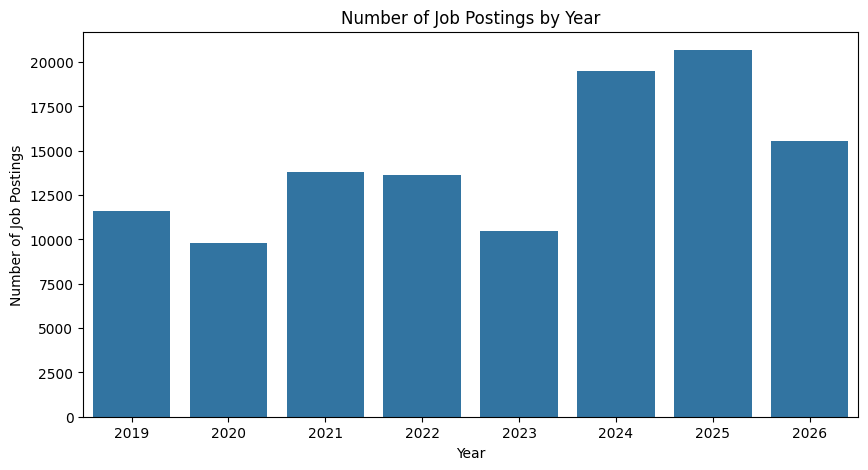

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=yearly_postings.index,
    y=yearly_postings.values
)

plt.title('Number of Job Postings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Job Postings')

plt.show()

### Observation

The number of job postings varies across the years covered by the dataset.
The year-wise distribution helps identify periods with relatively higher or
lower job-posting activity.

Job posting by months

In [ ]:
df['posting_month'] = df['posting_date'].dt.month

In [ ]:
monthly_postings = df['posting_month'].value_counts().sort_index()

print(monthly_postings)

posting_month
1     12558
2     12569
3     10312
4      9781
5      9823
6      9701
7      9800
8      9853
9      8605
10     8675
11     8580
12     4743
Name: count, dtype: int64


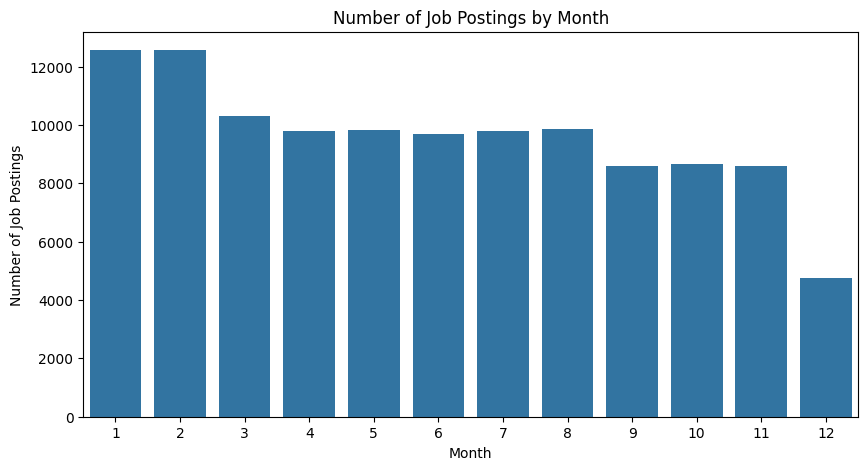

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_postings.index,
    y=monthly_postings.values
)

plt.title('Number of Job Postings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

plt.show()

### Observation

Job postings are distributed across all months, although the number of
postings varies from month to month. This analysis helps identify whether
there are noticeable seasonal differences in hiring activity.

Salary trend over years

In [ ]:
yearly_salary = df.groupby('posting_year')['avg_salary'].agg(
    ['count', 'mean', 'median']
).round(2)

yearly_salary

,count,mean,median
posting_year,,,
2019,11070,128364.45,116800.0
2020,9412,129083.95,117775.0
2021,13247,128142.82,116700.0
2022,13083,129100.77,117500.0
2023,10035,129225.09,117400.0
2024,18668,130105.3,117950.0
2025,19812,129011.42,116950.0
2026,14932,128924.39,117325.0


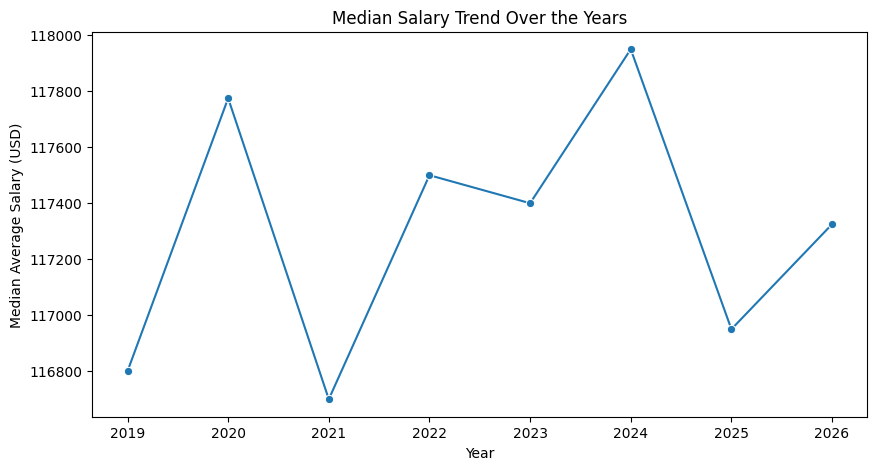

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_salary,
    x=yearly_salary.index,
    y='median',
    marker='o'
)

plt.title('Median Salary Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Median Average Salary (USD)')

plt.show()

### Observation

The yearly median salary shows how compensation levels have changed over
the period covered by the dataset. The trend indicates whether typical
salary levels have increased, decreased, or remained relatively stable
over time.

FEATURE ENGINEERING

In [ ]:

df['avg_salary'] = df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

In [ ]:
df[['salary_min_usd', 'salary_max_usd', 'avg_salary']].head(10)

,salary_min_usd,salary_max_usd,avg_salary
0,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>
2,238800.0,274700.0,256750.0
3,96300.0,104000.0,100150.0
4,186800.0,245400.0,216100.0
5,33100.0,38500.0,35800.0
6,87400.0,98100.0,92750.0
7,131100.0,103900.0,117500.0
8,114500.0,139700.0,127100.0
9,42500.0,47600.0,45050.0


In [ ]:
df['avg_salary'].describe()

,avg_salary
count,110259.0
mean,129051.768382
std,69741.823613
min,10300.0
25%,84750.0
50%,117300.0
75%,162000.0
max,1910150.0


The average salary is calculated from the minimum and maximum salary
values. It provides a single representative salary value for each
job posting.

In [ ]:
df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['date_position_filled'] = pd.to_datetime(df['date_position_filled'], errors='coerce')

In [ ]:
df['time_to_fill_days'] = (
    df['date_position_filled'] - df['posting_date']
).dt.days

In [ ]:
df[['posting_date', 'date_position_filled', 'time_to_fill_days']].head(10)

,posting_date,date_position_filled,time_to_fill_days
0,2023-09-21,2023-11-20,60.0
1,2025-05-11,NaT,NaN
2,2025-12-01,2026-02-08,69.0
3,2020-11-21,2020-12-21,30.0
4,2025-07-03,2025-09-15,74.0
5,2025-08-08,2025-09-09,32.0
6,2022-04-18,2022-06-09,52.0
7,2024-04-19,2024-05-29,40.0
8,2022-04-05,2022-08-17,134.0
9,2025-04-25,2025-05-05,10.0


In [ ]:
print(
    "Negative time-to-fill values:",
    (df['time_to_fill_days'] < 0).sum()
)

Negative time-to-fill values: 445


In [ ]:
df['offer_accept_ratio'] = np.where(
    df['offers_extended'] > 0,
    df['offers_accepted'] / df['offers_extended'],
    np.nan
)

In [ ]:
df[['offers_extended', 'offers_accepted', 'offer_accept_ratio']].head(10)

,offers_extended,offers_accepted,offer_accept_ratio
0,5.0,5.0,1.000000
1,1.0,0.0,0.000000
2,1.0,1.0,1.000000
3,6.0,5.0,0.833333
4,1.0,1.0,1.000000
5,1.0,1.0,1.000000
6,1.0,3.0,3.000000
7,1.0,1.0,1.000000
8,1.0,1.0,1.000000
9,1.0,1.0,1.000000


In [ ]:
df['offer_accept_ratio'].describe()

,offer_accept_ratio
count,105037.000000
mean,0.948221
std,0.223816
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


I calculated the difference between the position-filled date and posting date to understand how long companies take to fill positions

In [43]:
df['offer_accept_ratio'] = np.where(
    df['offers_extended'] > 0,
    df['offers_accepted'] / df['offers_extended'],
    np.nan
)

In [44]:
df[
    ['offers_extended',
     'offers_accepted',
     'offer_accept_ratio']
].head(10)

,offers_extended,offers_accepted,offer_accept_ratio
0,5.0,5.0,1.000000
1,1.0,0.0,0.000000
2,1.0,1.0,1.000000
3,6.0,5.0,0.833333
4,1.0,1.0,1.000000
5,1.0,1.0,1.000000
6,1.0,3.0,3.000000
7,1.0,1.0,1.000000
8,1.0,1.0,1.000000
9,1.0,1.0,1.000000


In [45]:
print(
    "Ratios below 0:",
    (df['offer_accept_ratio'] < 0).sum()
)

print(
    "Ratios above 1:",
    (df['offer_accept_ratio'] > 1).sum()
)

Ratios below 0: 0
Ratios above 1: 550


The following features were created:

- `avg_salary` – average of minimum and maximum salary.
- `time_to_fill_days` – number of days between job posting and position filled.
- `offer_accept_ratio` – accepted offers divided by extended offers.
